#Анализ дифференциальной экспрессии генов



# Часть 1 — DESeq2

## 0. Введение и описание задачи


Цель работы — выявить гены с достоверно изменённой экспрессией между двумя группами пациентов с раком лёгкого: **R** (responders, ответившие на лечение) и **NR** (non-responders, не ответившие)

### Данные

- **Тип данных:** RNA-seq (данные подсчёта ридов, raw counts).
- **Объект исследования:** Образцы биопсий рака лёгкого (LuC — Lung Cancer).
- **Группы:** R (responders) vs NR (non-responders).
- **Инструмент:** DESeq2 — использует отрицательное биномиальное распределение для моделирования счётных данных и вычисляет нормированные fold change с поправкой на дисперсию множественность измерений


---
## 1. PCA — анализ главных компонент

С помощью PCA  посмотрим насколько хорошо образцы разделяются по группам и есть ли нехарактерные образцы (выбросы) или технические артефакты (batch-эффект).


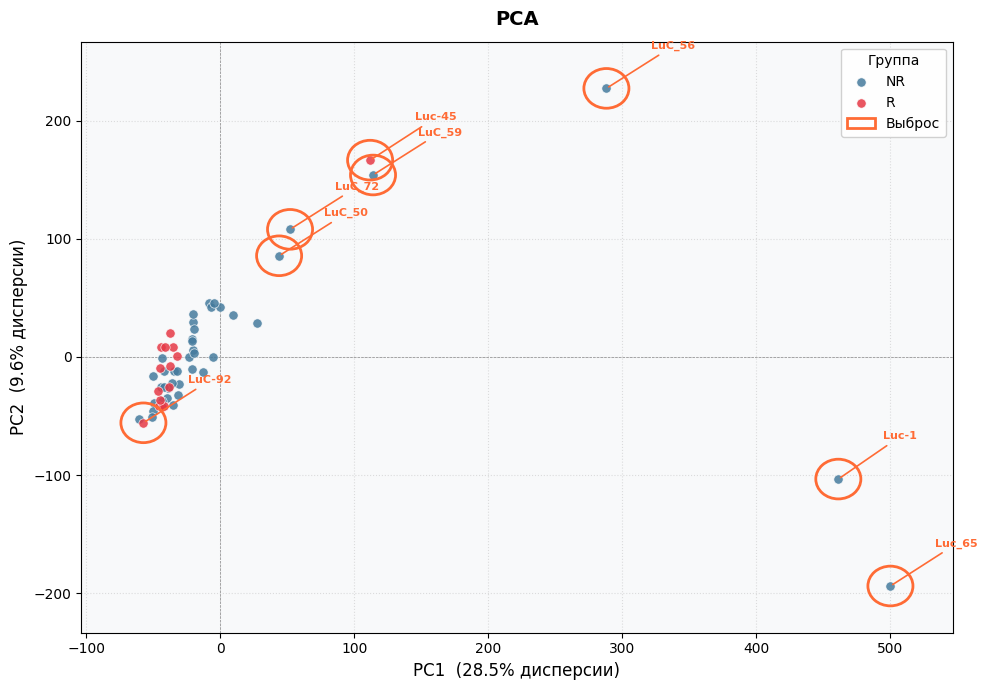

### Выводы:

На графике чётко видны несколько групп наблюдений:

1. **Основной кластер** (левая часть графика): большинство образцов R и NR сгруппированы вместе. Полного разделения групп нет, что типично для гетерогенных клинических данных

2. **Выбросы** (помечены оранжевыми кругами): обнаружено 8 выбросов — LuC-45, LuC_59, LuC_72, LuC_50, LuC_92, LuC_56, Luc-1, Luc_65. Они значительно удалены от основного кластера по PC1 и/или PC2, что свидетельствует об аномально высокой транскриптомной изменчивости

**Нужно ли удалять выбросы?**

Да. Образцы-выбросы могут:
- исказить оценку дисперсии в DESeq2
- снизить мощность статистического теста
- создать ложноположительные или ложноотрицательные результаты


**Batch-эффект:** Явного batch-эффекта (систематической группировки образцов по техническому фактору, не связанному с биологией) на PCA не наблюдается. Основной кластер выглядит однородным, поэтому коррекция batch-эффекта не требуется



## 2. Clustermap образцов

Сlustermap строим по топ-200 генам с наибольшей дисперсией экспрессии. Значения нормированы как Z-score по генам

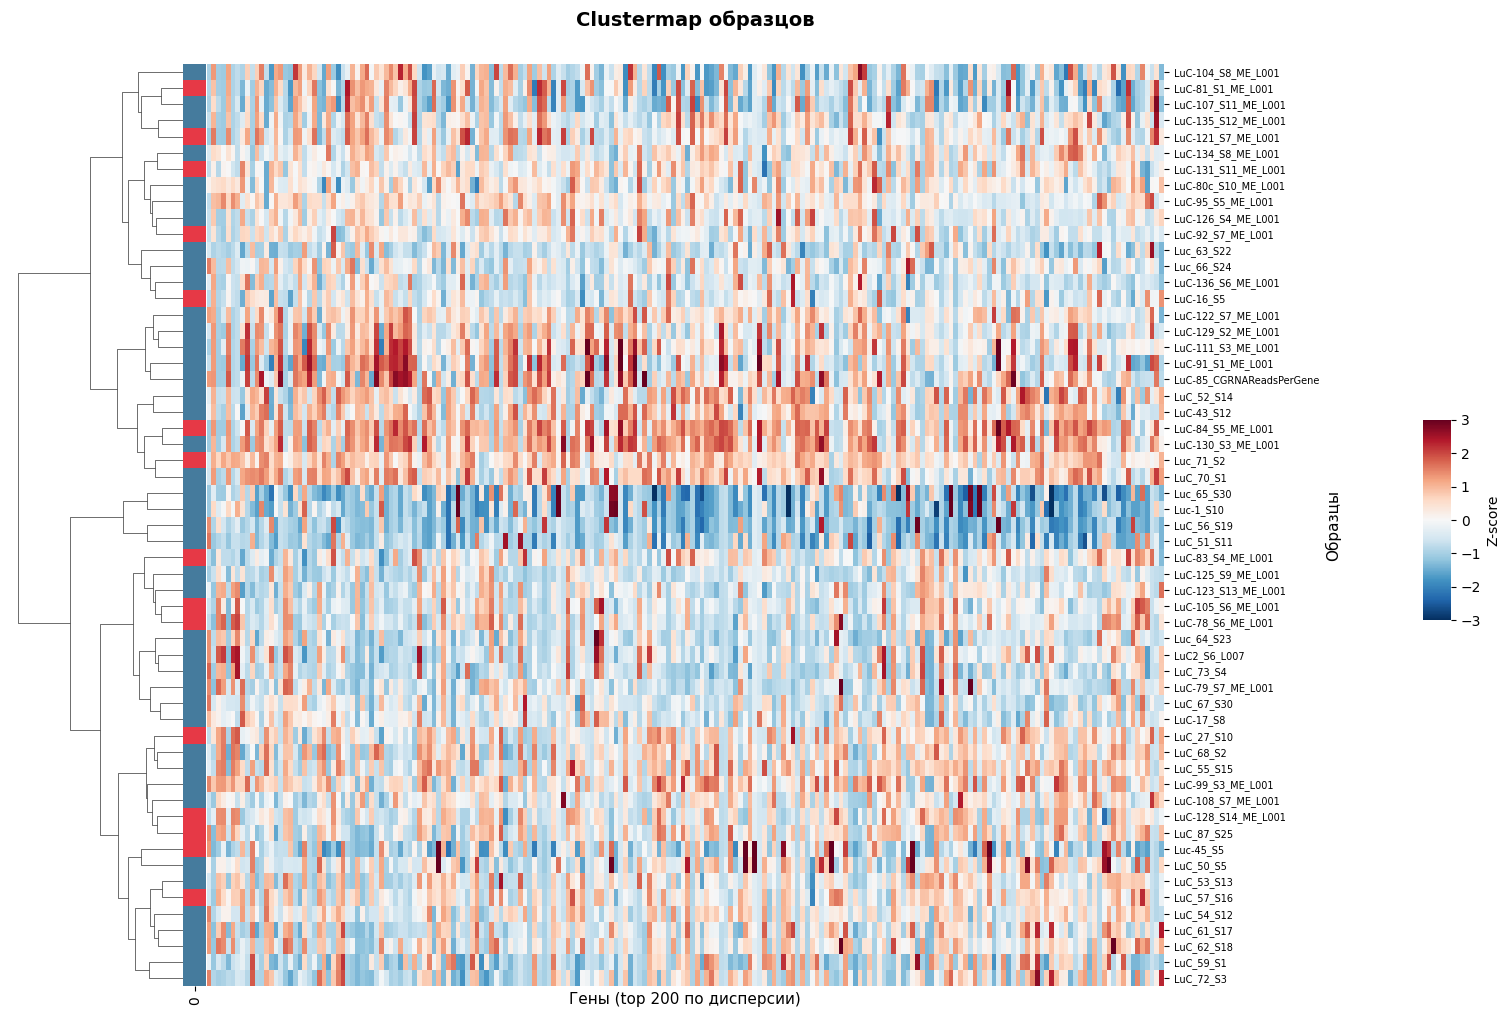

### Выводы

Образцы-выбросы из PCA (LuC-1, LuC_65, LuC_56) формируют обособленные строки внутри нижнего кластера, что дополнительно подтверждает обоснованность их исключения из дальнейшего анализа.

Чёткого разделения кластеров по группам R/NR не наблюдается, что указывает на транскриптомную гетерогенность внутри групп

---
## 3. Анализ дифференциально экспрессированных генов

После исключения выбросов, выявленных на PCA, запущен DESeq2

Ниже представлена таблица топ-16 наиболее значимых DEG:


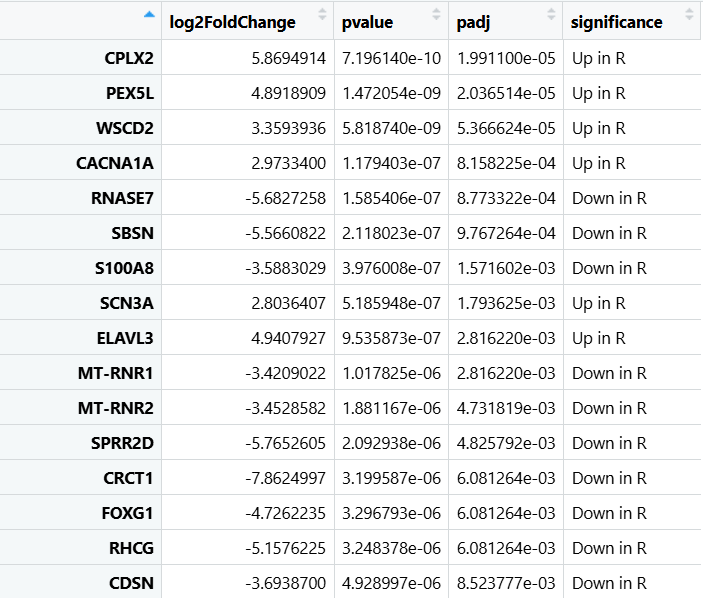

### Интерпретация таблицы

- **CPLX2** — ген комплексина-2, участвующего в нейрональном везикулярном транспорте.
- **MT-RNR1, MT-RNR2** — митохондриальные гены рибосомальной РНК; их снижение в группе R может указывать на изменения митохондриальной функции.
- **S100A8, SPRR2D, CRCT1, CDSN** — маркеры плоского эпителия и воспаления, снижены у ответивших


---
## 4. Volcano plot

Volcano plot отображает соотношение статистической значимости (−log10 padj) и величины изменения экспрессии (log2FoldChange). Пороги: padj < 0.01, |log2FC| > 2.


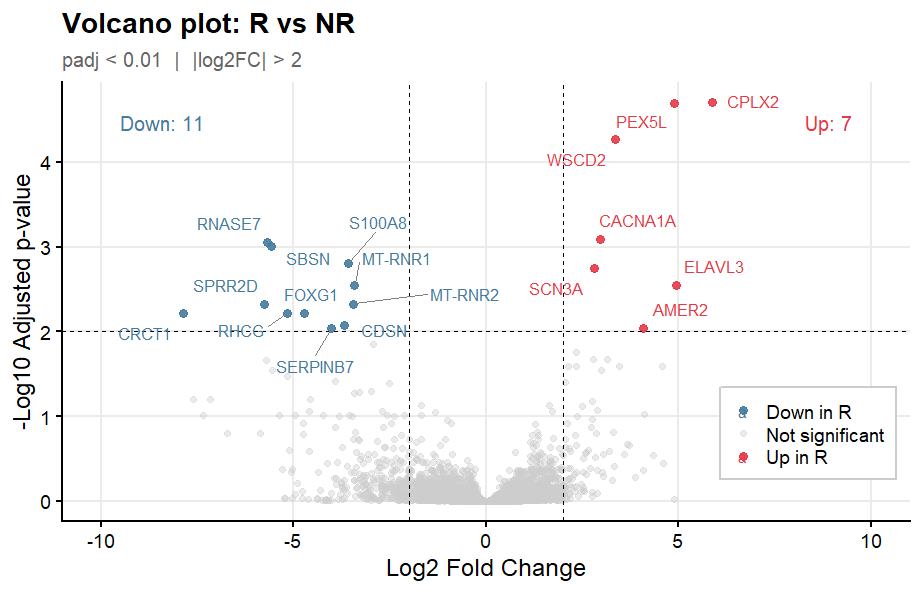

### Выводы

- При выбранных порогах обнаружено 7 генов Up in R и 11 генов Down in R
- Большинство генов располагаются в «облаке» с низкой значимостью — типичная картина для клинических RNA-seq с высокой биологической вариабельностью



## 5. Выводы по Части 1

1. **PCA** выявил 8 образцов-выбросов, которые были исключены из анализа. Batch-эффект не обнаружен.
2. **Clustermap** подтвердил гетерогенность образцов: два крупных кластера, не совпадающих строго с разделением R/NR.
3. Повышенные в R гены связаны преимущественно с нейрональными функциями, что может отражать нейроэндокринные особенности опухолей у ответивших пациентов
4. Сниженные в R гены включают маркеры воспаления, что согласуется с более ограниченным воспалительным микроокружением у ответивших на лечение


---
# Часть 2 — LIMMA

##0. Введение и обоснование выбора метода

В этой части анализируются данные microarray экспериментов.В Affymetrix чипах - данные представлены в виде непрерывных интенсивностей флуоресценции, прошедших предварительную нормализацию
### Почему LIMMA, а не DESeq2

**LIMMA** (Linear Models for Microarray Analysis) использует линейные модели и эмпирический байесовский подход для оценки дисперсии, что критически важно при малых выборках. Для данных микрочипов, где экспрессия представлена в виде непрерывных нормализованных значений (логарифмированных интенсивностей), использование DESeq2 некорректно.

Анализ также сравнивает две группы (по аналогии с Частью 1), но разность — **pCR vs non-pCR** (патологический полный ответ vs нет).



## 1. Таблица результатов LIMMA с дополнительными столбцами

Таблица содержит результаты LIMMA с добавленными столбцами значимости:
- `sig_adjP_lfc1/2/3` — значимость с поправкой на множественные сравнения (adj.P.Val < 0.05) при соответствующем пороге |logFC|
- `sig_pval_lfc1/2/3` — значимость по raw p-value < 0.05 при соответствующем пороге |logFC|

Символ `+` означает значимость, `−` — нет.


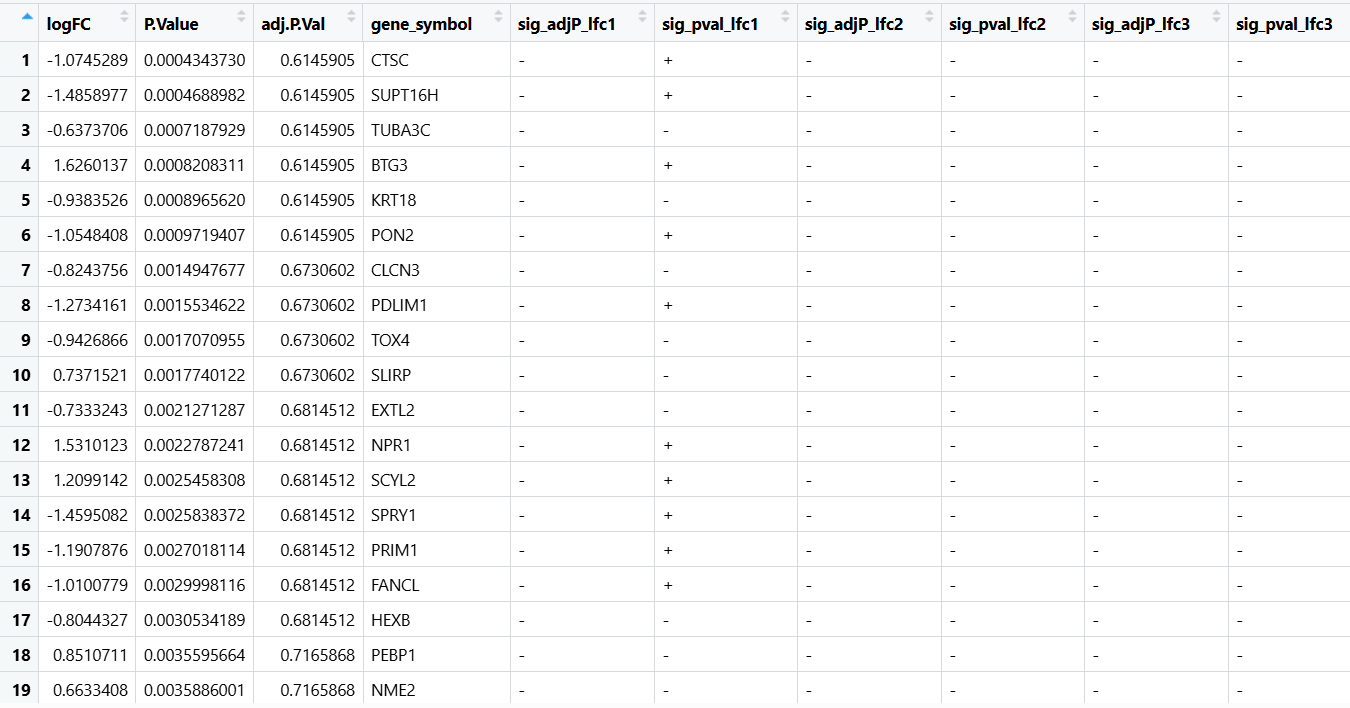

### Ключевые наблюдения из таблицы

- Ни один ген не проходит порог по adj.P.Val (все `sig_adjP_lfc*` = `−`). Это означает, что после поправки Бенджамини-Хохберга нет статистически значимых генов
- Отсутствие значимых генов после поправки может объясняться малым размером выборки, что снижает статистическую мощность.



## 2. Volcano plots при разных порогах |logFC|

Для оценки чувствительности анализа к выбору порога логарифмического fold change построем три volcano plot: при |logFC| > 1, > 2 и > 3. Порог по p-value: **raw p < 0.05** (без поправки на множественные сравнения — adj.P.Val не проходит порог).


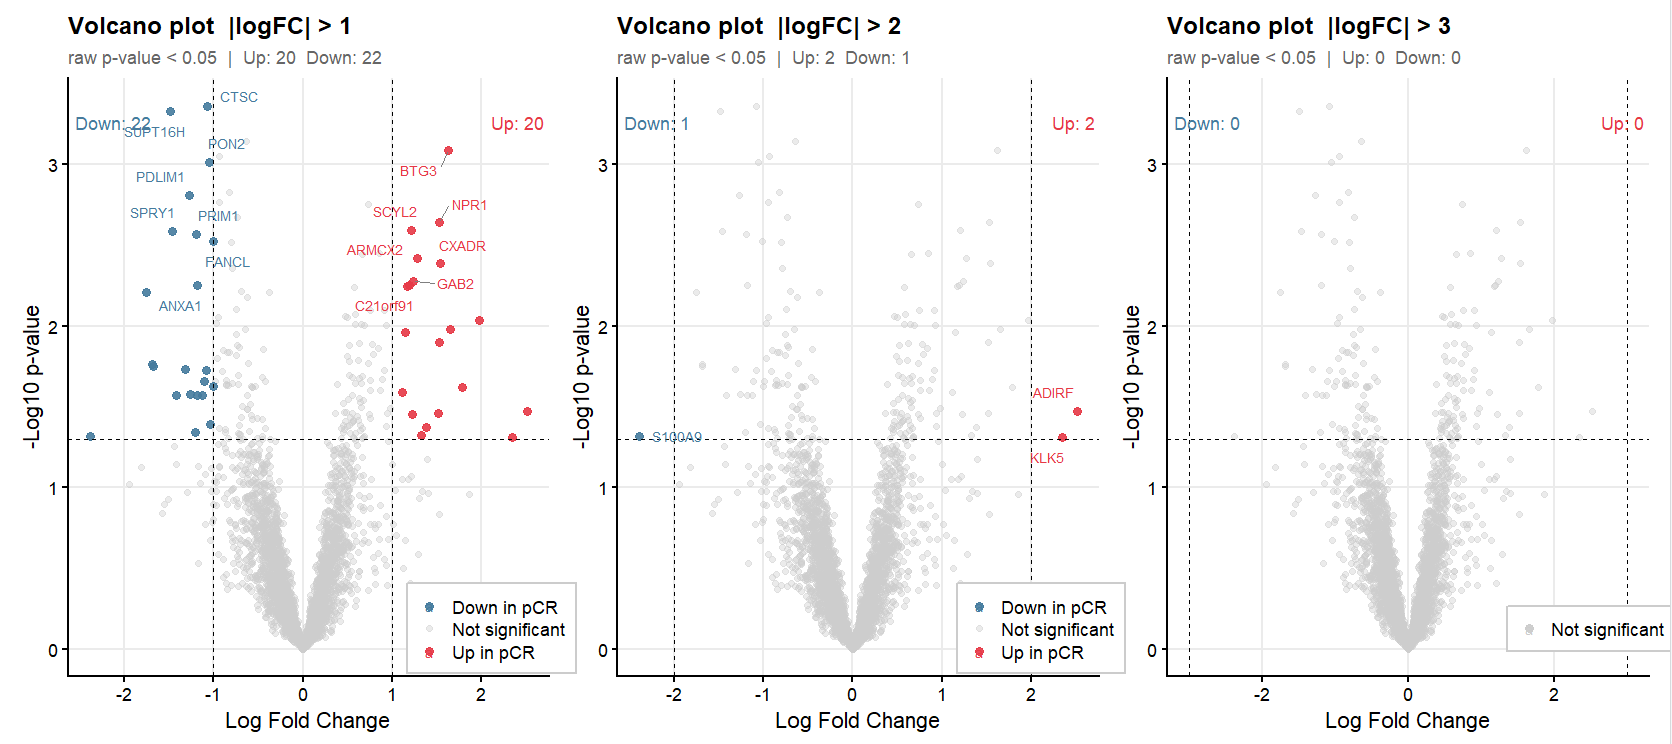

### Какой порог выбрать?

Для данного анализа рекомендуется **|logFC| > 1**. Обоснование:

- Данные микрочипов имеют меньший динамический диапазон, чем RNA-seq: fold change > 4 (log2FC > 2) — редкость для нормализованных интенсивностей чипов.
- При |logFC| > 2 находится лишь 3 гена — статистически нерепрезентативный набор для биологических выводов.
- При |logFC| > 1 обнаруживается достаточное количество генов (42) для последующего анализа.
- **Важная оговорка:** adj.P.Val при любом пороге не проходит коррекцию множественных сравнений, поэтому результаты носят **предварительный** характер и требуют валидации.



## Выводы по Части 2

1. **LIMMA** является методом выбора для данного анализа, так как данные получены с микрочипов и представляют собой непрерывные нормализованные значения.

2. **Оптимальный порог |logFC| = 1**: при более строгих порогах (2, 3) число значимых генов резко падает до 3 и 0 соответственно, что делает биологическую интерпретацию невозможной.

3. При выбранном пороге (|logFC| > 1, raw p < 0.05) обнаружено **42 гена**: 20 Up и 22 Down в группе pCR.

4. Среди наиболее интересных кандидатов: **BTG3** (антипролиферативный ген, Up в pCR), **NPR1** (рецептор натрийуретического пептида), **CTSC** и **SUPT16H** (хроматин-ремоделирующий фактор, Down в pCR).

